# 🔢 Notebook 03 — Vectorización

Convertimos el texto limpio a números que el modelo puede procesar.
Comparamos **TF-IDF** vs **Bag of Words** y analizamos qué features
captura cada uno.

El modelo no ve palabras, ve números. Cómo transformemos el texto
define directamente qué puede aprender el modelo.
Un mal vectorizador hace imposible un buen modelo.

### ¿Por qué TF-IDF sobre BoW en este dataset?
- BoW cuenta apariciones brutas: 'the' pesa igual que 'thug'
- TF-IDF penaliza palabras frecuentes en todos los docs y premia
  las que discriminan entre clases
- Con mediana de 9 tokens por comentario, cada palabra cuenta

## 0. Imports y configuración

In [2]:
print("Kernel")

Kernel


In [3]:
import sys
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import issparse
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f'PROJECT_ROOT: {PROJECT_ROOT}')

/home/under/miniconda3/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT


In [4]:
# Carga de configuracion
CONFIG_FEAT = PROJECT_ROOT / 'configs' / 'features.yaml'
CONFIG_PIPE = PROJECT_ROOT / 'configs' / 'pipeline.yaml'

with open(CONFIG_FEAT) as f: feat_cfg = yaml.safe_load(f)
with open(CONFIG_PIPE) as f: pipe_cfg = yaml.safe_load(f)

vec_cfg    = feat_cfg['vectorization']
tfidf_cfg  = vec_cfg['tfidf']
bow_cfg    = vec_cfg['bow']
TARGET_BIN = pipe_cfg['data']['target_binary']
SUBLABELS  = pipe_cfg['data']['target_multilabel']
RAND_STATE = pipe_cfg['pipeline']['random_state']
TEST_SIZE  = pipe_cfg['pipeline']['test_size']

print('TF-IDF config:', tfidf_cfg)
print('BoW config    :', bow_cfg)
print(f'random_state  : {RAND_STATE} | test_size: {TEST_SIZE}')

TF-IDF config: {'max_features': 5000, 'ngram_range': [1, 2], 'sublinear_tf': True, 'min_df': 3}
BoW config    : {'max_features': 5000, 'ngram_range': [1, 1], 'min_df': 3}
random_state  : 42 | test_size: 0.2


## 1. Carga del texto preprocesado

Usamos el CSV generado por el notebook de preprocesamiento.
**Nunca** vectorizamos texto crudo.

In [5]:
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'v2' / 'comments_preprocessed.csv'

df = pd.read_csv(PROCESSED_PATH)
print(f'Dataset: {df.shape}')
print(f'Nulos en clean_text: {df["clean_text"].isnull().sum()}')
print(f'Vacios en clean_text: {(df["clean_text"] == "").sum()}')

# Rellenar vacios con placeholder para no romper el vectorizador
df['clean_text'] = df['clean_text'].fillna('').astype(str)

print(f'\nDistribucion target:')
print(df[TARGET_BIN].value_counts())
print()
print('Muestra texto limpio:')
for t in df['clean_text'].sample(4, random_state=42):
    print(f'  {repr(t[:80])}')

Dataset: (1000, 9)
Nulos en clean_text: 0
Vacios en clean_text: 0

Distribucion target:
IsToxic
False    538
True     462
Name: count, dtype: int64

Muestra texto limpio:
  'call anarchist defend cop shoot unarmed civilian highly disappointed beginning r'
  'mother tell I thing god bless woman'
  'love saem thing go stupid ya kill ya self quick stlpd could ever wakeup'
  'next time line car start make burnout smoke riot gas non lethal eficient double '


## 2. Train / Test split

El split se hace **antes** de vectorizar para evitar data leakage.

> ⚠️ **Data leakage**: si vectorizas todo el dataset y luego splitteas,
> el vectorizador ha 'visto' el test set durante el fit. El vocabulario
> y los IDF scores estarán contaminados con datos de test.
> Resultado: métricas optimistas que no se replican en producción.

**Regla:** fit del vectorizador **solo** sobre X_train. Transform sobre ambos.

In [6]:
X = df['clean_text']
y_bin = df[TARGET_BIN]
y_multi = df[SUBLABELS]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin,
    test_size=TEST_SIZE,
    random_state=RAND_STATE,
    stratify=y_bin          # misma proporcion toxic/no-toxic en train y test
)

print(f'Train : {len(X_train)} muestras')
print(f'Test  : {len(X_test)} muestras')
print()
print('Distribucion train:')
print(y_train.value_counts())
print()
print('Distribucion test:')
print(y_test.value_counts())

Train : 800 muestras
Test  : 200 muestras

Distribucion train:
IsToxic
False    430
True     370
Name: count, dtype: int64

Distribucion test:
IsToxic
False    108
True      92
Name: count, dtype: int64


## 3. TF-IDF — Term Frequency Inverse Document Frequency

### ¿Cómo funciona?
Para cada palabra en cada documento calcula:
```
TF-IDF(palabra, doc) = TF(palabra, doc) × IDF(palabra)

TF  = frecuencia de la palabra en este documento
IDF = log(total docs / docs que contienen la palabra)
```
**Resultado:** palabras raras pero relevantes tienen peso alto.
Palabras que aparecen en todos los docs (como 'said') tienen peso bajo.

### Por qué `sublinear_tf=True`
Sin esto, un comentario que dice 'kill' 10 veces pesa 10x más que uno que lo dice 1 vez.
Con `sublinear_tf`: `TF = 1 + log(count)` → escala logarítmica más razonable.

### Por qué `ngram_range=(1,2)`
Con solo unigramas: 'black' tiene el mismo peso en tóxico y no tóxico.
Con bigramas: 'black thug', 'black criminal' aparecen casi solo en tóxicos.

In [7]:
# Fit SOLO sobre train — nunca sobre todo el dataset
tfidf = TfidfVectorizer(
    max_features = tfidf_cfg['max_features'],
    ngram_range  = tuple(tfidf_cfg['ngram_range']),
    sublinear_tf = tfidf_cfg['sublinear_tf'],
    min_df       = tfidf_cfg['min_df'],
    analyzer     = 'word',
    strip_accents= 'unicode',
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit + transform sobre train
X_test_tfidf  = tfidf.transform(X_test)        # solo transform sobre test

print(f'Vocabulario TF-IDF : {len(tfidf.vocabulary_):,} features')
print(f'Shape X_train      : {X_train_tfidf.shape}')
print(f'Shape X_test       : {X_test_tfidf.shape}')
print(f'Tipo de matriz     : {type(X_train_tfidf).__name__} (sparse)')
print()

# Esparsidad: que % de valores son 0
total = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
nonzero = X_train_tfidf.nnz
sparsity = (1 - nonzero / total) * 100
print(f'Valores no-cero    : {nonzero:,} de {total:,}')
print(f'Esparsidad         : {sparsity:.1f}%')
print()
print('Ejemplo 5 features del vocabulario:')
vocab_sample = list(tfidf.vocabulary_.items())[:5]
for word, idx in vocab_sample:
    print(f'  "{word}" -> columna {idx}')

Vocabulario TF-IDF : 1,080 features
Shape X_train      : (800, 1080)
Shape X_test       : (200, 1080)
Tipo de matriz     : csr_matrix (sparse)

Valores no-cero    : 10,010 de 864,000
Esparsidad         : 98.8%

Ejemplo 5 features del vocabulario:
  "wonder" -> columna 1050
  "police" -> columna 697
  "expect" -> columna 298
  "happen" -> columna 406
  "abuse" -> columna 2


## 4. Análisis de features: ¿qué captura TF-IDF?

Identificamos las palabras y bigramas con mayor peso promedio
en comentarios tóxicos vs no tóxicos.
Esto nos dice si el vectorizador está capturando las señales correctas.

In [8]:
# Media de TF-IDF por feature para cada clase
# Usamos el indice del train set para separar por clase
y_train_arr = y_train.values
mask_toxic    = y_train_arr == True
mask_nontoxic = y_train_arr == False

# Media de cada feature en comentarios toxicos vs no toxicos
mean_toxic    = np.asarray(X_train_tfidf[mask_toxic].mean(axis=0)).flatten()
mean_nontoxic = np.asarray(X_train_tfidf[mask_nontoxic].mean(axis=0)).flatten()

feature_names = tfidf.get_feature_names_out()

feat_df = pd.DataFrame({
    'feature'   : feature_names,
    'toxic'     : mean_toxic,
    'nontoxic'  : mean_nontoxic,
    'diff'      : mean_toxic - mean_nontoxic
})

print('TOP 20 features mas discriminantes para TOXICO:')
print(feat_df.nlargest(20, 'diff')[['feature','toxic','nontoxic','diff']].to_string(index=False))
print()
print('TOP 20 features mas discriminantes para NO TOXICO:')
print(feat_df.nsmallest(20, 'diff')[['feature','toxic','nontoxic','diff']].to_string(index=False))

TOP 20 features mas discriminantes para TOXICO:
 feature    toxic  nontoxic     diff
     run 0.042961  0.004840 0.038121
    fuck 0.033135  0.002391 0.030743
   idiot 0.022376  0.000594 0.021782
    shit 0.021520  0.001077 0.020443
     ass 0.017156  0.000687 0.016469
   shoot 0.029257  0.013242 0.016014
   bitch 0.015259  0.000559 0.014701
  stupid 0.016642  0.002210 0.014432
    thug 0.014311  0.001864 0.012447
    dumb 0.011687  0.000672 0.011015
 fucking 0.012428  0.002065 0.010363
    cunt 0.010253  0.000000 0.010253
   white 0.024497  0.015250 0.009247
   black 0.033891  0.025289 0.008601
  racist 0.019317  0.010835 0.008482
     cnn 0.014236  0.006085 0.008151
bullshit 0.008150  0.000000 0.008150
    kill 0.016292  0.008181 0.008111
     get 0.036290  0.028203 0.008088
   every 0.010437  0.002884 0.007553

TOP 20 features mas discriminantes para NO TOXICO:
feature    toxic  nontoxic      diff
  thank 0.004184  0.023202 -0.019018
  truth 0.002759  0.015370 -0.012611
    say 0.01

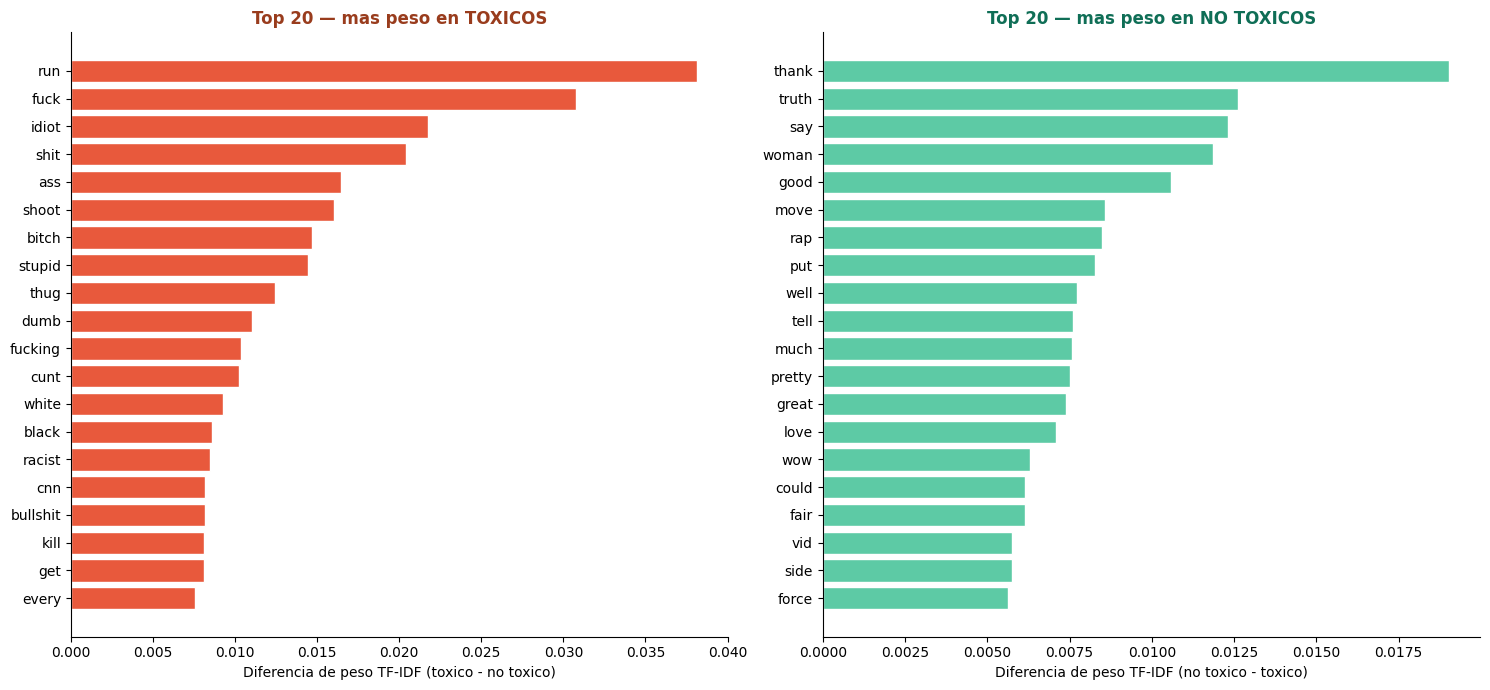

Guardado en reports/08_tfidf_top_features.png


In [9]:
# Visualizacion: top features por clase
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Top toxic
top_toxic = feat_df.nlargest(20, 'diff')
axes[0].barh(top_toxic['feature'], top_toxic['diff'], color='#E8593C', edgecolor='white')
axes[0].set_title('Top 20 — mas peso en TOXICOS', fontweight='bold', color='#993C1D')
axes[0].set_xlabel('Diferencia de peso TF-IDF (toxico - no toxico)')
axes[0].invert_yaxis()

# Top non-toxic
top_nontoxic = feat_df.nsmallest(20, 'diff')
axes[1].barh(top_nontoxic['feature'], top_nontoxic['diff'].abs(), color='#5DCAA5', edgecolor='white')
axes[1].set_title('Top 20 — mas peso en NO TOXICOS', fontweight='bold', color='#0F6E56')
axes[1].set_xlabel('Diferencia de peso TF-IDF (no toxico - toxico)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'v2' / '08_tfidf_top_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado en reports/08_tfidf_top_features.png')

In [10]:
# Analisis de bigramas: los mas discriminantes
bigrams_df = feat_df[feat_df['feature'].str.contains(' ')]  # bigramas tienen espacio
unigrams_df = feat_df[~feat_df['feature'].str.contains(' ')]

print(f'Unigramas en vocabulario : {len(unigrams_df):,}')
print(f'Bigramas en vocabulario  : {len(bigrams_df):,}')
print()
print('TOP 15 bigramas toxicos:')
print(bigrams_df.nlargest(15, 'diff')[['feature','diff']].to_string(index=False))
print()
print('TOP 15 bigramas no toxicos:')
print(bigrams_df.nsmallest(15, 'diff')[['feature','diff']].to_string(index=False))

Unigramas en vocabulario : 896
Bigramas en vocabulario  : 184

TOP 15 bigramas toxicos:
        feature     diff
      get shoot 0.005374
     piece shit 0.005267
      guy idiot 0.004208
        get hit 0.003931
shoot apprehend 0.003739
        get way 0.003618
  rubber bullet 0.003527
law enforcement 0.003480
        go back 0.003297
       dumb ass 0.003264
      joe rogan 0.003253
       get kill 0.003235
        get job 0.003189
   black people 0.002941
  block traffic 0.002768

TOP 15 bigramas no toxicos:
         feature      diff
        mr brown -0.003882
      police car -0.003806
      people say -0.003721
african american -0.003534
  police officer -0.003099
 black community -0.003013
     pretty much -0.002829
       rap lyric -0.002811
       god bless -0.002736
      tell truth -0.002614
     black woman -0.002318
     mr molyneux -0.002261
 majority people -0.002251
    deadly force -0.002221
    people would -0.002150


## 5. Bag of Words — comparación

BoW simplemente cuenta cuántas veces aparece cada palabra.
Lo entrenamos con los mismos parámetros para comparar con TF-IDF.

**Diferencia clave:**
- BoW: comentario largo con 'stupid' 3 veces → peso 3
- TF-IDF: mismo comentario → peso log(3)×IDF('stupid')
- TF-IDF penaliza 'stupid' si aparece en muchos docs, BoW no.

In [11]:
bow = CountVectorizer(
    max_features = bow_cfg['max_features'],
    ngram_range  = tuple(bow_cfg['ngram_range']),
    min_df       = bow_cfg['min_df'],
    analyzer     = 'word',
    strip_accents= 'unicode',
)

X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

print(f'Vocabulario BoW : {len(bow.vocabulary_):,} features')
print(f'Shape X_train   : {X_train_bow.shape}')
print(f'Shape X_test    : {X_test_bow.shape}')

Vocabulario BoW : 896 features
Shape X_train   : (800, 896)
Shape X_test    : (200, 896)


In [12]:
# Comparativa de esparsidad y vocabulario
tfidf_sparse = (1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1])) * 100
bow_sparse   = (1 - X_train_bow.nnz / (X_train_bow.shape[0]*X_train_bow.shape[1])) * 100

print(f"{'':25} {'TF-IDF':>12} {'BoW':>12}")
print('-' * 52)
print(f"  {'Vocabulario':23} {len(tfidf.vocabulary_):>12,} {len(bow.vocabulary_):>12,}")
print(f"  {'Shape train':23} {str(X_train_tfidf.shape):>12} {str(X_train_bow.shape):>12}")
print(f"  {'Esparsidad':23} {tfidf_sparse:>11.1f}% {bow_sparse:>11.1f}%")
print(f"  {'Valores no-cero':23} {X_train_tfidf.nnz:>12,} {X_train_bow.nnz:>12,}")

                                TF-IDF          BoW
----------------------------------------------------
  Vocabulario                    1,080          896
  Shape train              (800, 1080)   (800, 896)
  Esparsidad                     98.8%        98.7%
  Valores no-cero               10,010        9,127


## 6. Registro en MLflow

Registramos la configuración del vectorizador y las métricas de vocabulario.
En el siguiente notebook (baseline) compararemos si TF-IDF o BoW da mejor F1.

In [13]:
MLFLOW_DIR = PROJECT_ROOT / 'mlruns'
mlflow.set_tracking_uri(f'file://{MLFLOW_DIR}')
mlflow.set_experiment('Youtube_project_data')

with mlflow.start_run(run_name='tfidf_vs_bow'):

    # Params del vectorizador
    mlflow.log_param('tfidf_max_features', tfidf_cfg['max_features'])
    mlflow.log_param('tfidf_ngram_range',  str(tuple(tfidf_cfg['ngram_range'])))
    mlflow.log_param('tfidf_sublinear_tf', tfidf_cfg['sublinear_tf'])
    mlflow.log_param('tfidf_min_df',       tfidf_cfg['min_df'])
    mlflow.log_param('bow_max_features',   bow_cfg['max_features'])
    mlflow.log_param('bow_ngram_range',    str(tuple(bow_cfg['ngram_range'])))
    mlflow.log_param('train_size',         len(X_train))
    mlflow.log_param('test_size',          len(X_test))
    mlflow.log_param('random_state',       RAND_STATE)

    # Metrics
    mlflow.log_metric('tfidf_vocab_size',   len(tfidf.vocabulary_))
    mlflow.log_metric('tfidf_sparsity_pct', round(tfidf_sparse, 2))
    mlflow.log_metric('bow_vocab_size',     len(bow.vocabulary_))
    mlflow.log_metric('bow_sparsity_pct',   round(bow_sparse, 2))
    mlflow.log_metric('n_bigrams_tfidf',    len(bigrams_df))
    mlflow.log_metric('n_unigrams_tfidf',   len(unigrams_df))

    # Artefactos
    mlflow.log_artifact(str(PROJECT_ROOT / 'reports' / 'v2' / '08_tfidf_top_features.png'))
    mlflow.log_artifact(str(CONFIG_FEAT))

    print(f'MLflow run registrado')
    print(f'  Run ID     : {mlflow.active_run().info.run_id}')
    print(f'  Experimento: Youtube_project_data')

MLflow run registrado
  Run ID     : 03dee0fc689c48f98491cd212cd14756
  Experimento: Youtube_project_data


## 7. Conclusiones y decisiones

In [14]:
print(f"""
CONCLUSIONES — VECTORIZACION
{'='*55}
Configuracion elegida:
  Metodo   : TF-IDF
  n-gramas : (1, 2) — unigramas + bigramas
  max_feat : {tfidf_cfg['max_features']:,}
  min_df   : {tfidf_cfg['min_df']} — filtra palabras en <{tfidf_cfg['min_df']} docs
  sublinear: True — escala logaritmica

Resultado:
  Vocabulario  : {len(tfidf.vocabulary_):,} features
  Shape train  : {X_train_tfidf.shape}
  Shape test   : {X_test_tfidf.shape}
  Esparsidad   : {tfidf_sparse:.1f}%

Por que TF-IDF > BoW en este dataset:
  - 'black' aparece en ambas clases -> BoW no discrimina
  - TF-IDF baja el peso de palabras ubicuas
  - Bigramas capturan 'black thug', 'kill cop' como una unidad
  - Con 9 tokens medios por doc, el IDF marca diferencias claras

Objetos disponibles para el siguiente notebook:
  X_train_tfidf -> matriz sparse train
  X_test_tfidf  -> matriz sparse test
  y_train       -> labels train
  y_test        -> labels test
  tfidf         -> vectorizador entrenado
""")


CONCLUSIONES — VECTORIZACION
Configuracion elegida:
  Metodo   : TF-IDF
  n-gramas : (1, 2) — unigramas + bigramas
  max_feat : 5,000
  min_df   : 3 — filtra palabras en <3 docs
  sublinear: True — escala logaritmica

Resultado:
  Vocabulario  : 1,080 features
  Shape train  : (800, 1080)
  Shape test   : (200, 1080)
  Esparsidad   : 98.8%

Por que TF-IDF > BoW en este dataset:
  - 'black' aparece en ambas clases -> BoW no discrimina
  - TF-IDF baja el peso de palabras ubicuas
  - Bigramas capturan 'black thug', 'kill cop' como una unidad
  - Con 9 tokens medios por doc, el IDF marca diferencias claras

Objetos disponibles para el siguiente notebook:
  X_train_tfidf -> matriz sparse train
  X_test_tfidf  -> matriz sparse test
  y_train       -> labels train
  y_test        -> labels test
  tfidf         -> vectorizador entrenado

